# Graph Laplacian

In this notebook we compute and visualize geometric information from synthetic point cloud datasets sampled from various low-dimensional manifolds, using the implementation in `laplace.py` and the visualization helpers in `visualizations.py`.

### Results: Tangent Bundle

The following cell finds the tangent plane estimates for a torus and a hyperboloid of one sheet, plotting a small segment of the plane spanned by the computed basis for the tangent space at each point.

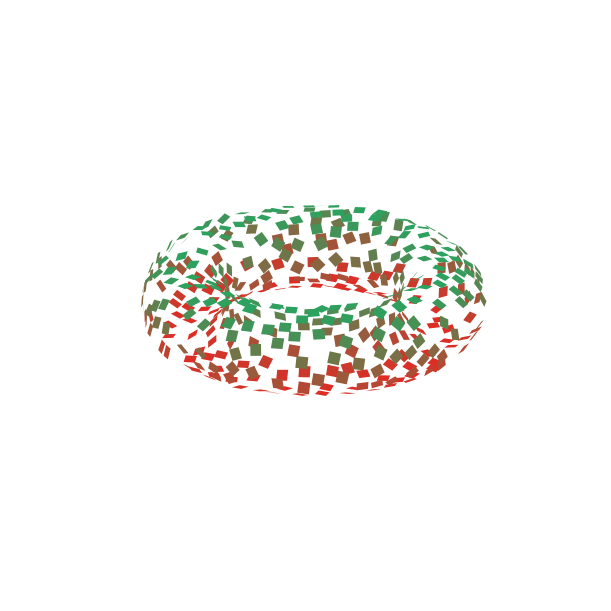

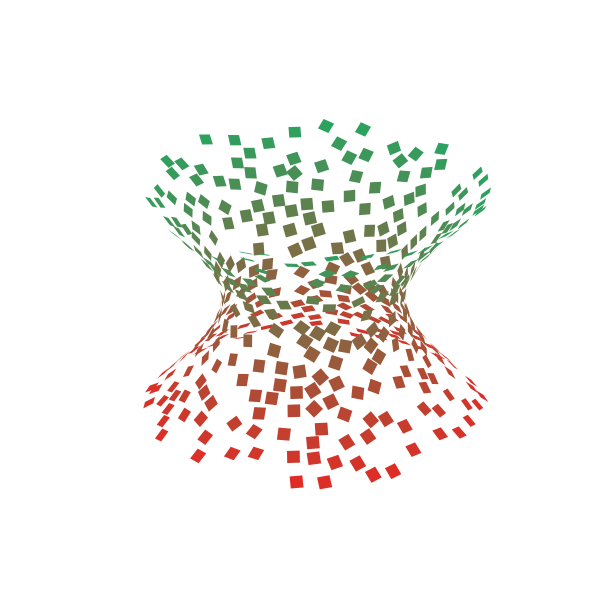

In [1]:
from visualizations import *

points = sample_torus()
tangent_bundle, _, _ = tangents(points, 32)
plot_tangent_plane_collection(points, tangent_bundle)

points = sample_one_sheet_hyperboloid()
tangent_bundle, _, _ = tangents(points, 32)
plot_tangent_plane_collection(points, tangent_bundle)
plt.show()


### Results: Pointwise Dimension Estimation

This cell samples points from a square in the plane and a swiss roll in 3-space, and then computes the pointwise dimension estimates. We plot all the datapoints colored by the estimated dimension.

square: {'score': 0.8134210526315789, 'interior_acc': 0.8068421052631579, 'boundary_acc': 0.82, 'median_dim': 2, 'hist': {0: 29, 1: 428, 2: 1543}}
swiss roll: {'score': 0.7127941176470588, 'interior_acc': 0.8605882352941177, 'boundary_acc': 0.565, 'median_dim': 2, 'hist': {0: 31, 1: 806, 2: 3163}}


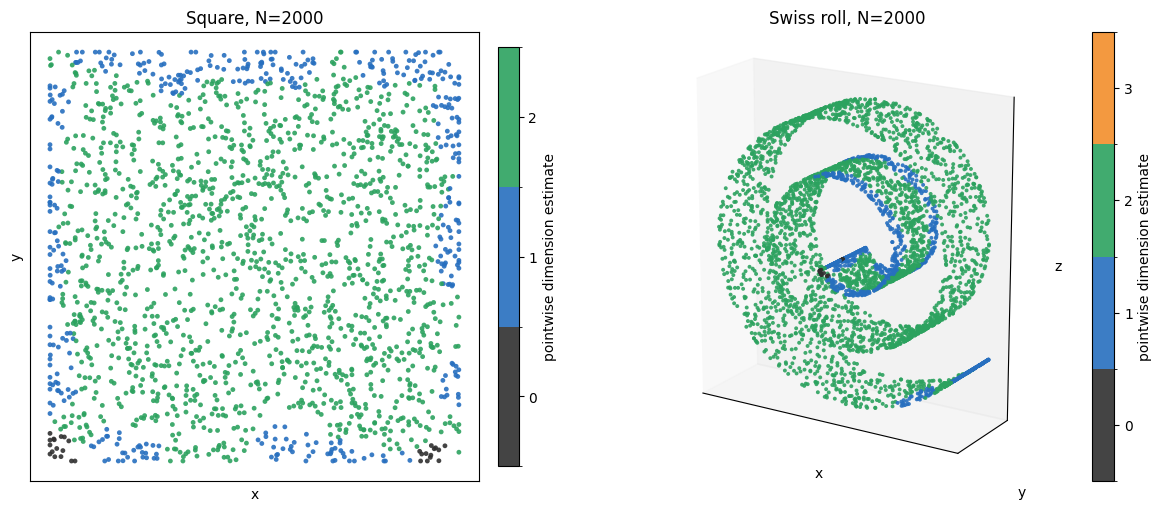

In [2]:
side_by_side_square, side_by_side_square_boundary = sample_square(2000)
side_by_side_swiss, side_by_side_swiss_boundary = sample_swiss_roll(4000)
side_by_side_square_dims = estimate_dim(side_by_side_square, n0=52)
side_by_side_swiss_dims = estimate_dim(side_by_side_swiss, n0=52)

side_by_side_fig = plt.figure(figsize=(11.5, 5.0), constrained_layout=True)
gs = side_by_side_fig.add_gridspec(1, 2, width_ratios=(1.0, 1.1))
square_ax = side_by_side_fig.add_subplot(gs[0, 0])
swiss_ax = side_by_side_fig.add_subplot(gs[0, 1], projection="3d")
plot_dims(square_ax, side_by_side_square, side_by_side_square_dims, "Square, N=2000", 12)
plot_dims(swiss_ax, side_by_side_swiss, side_by_side_swiss_dims, "Swiss roll, N=2000", 8, 18, -58)

square_cbar_ax, swiss_cbar_ax = [ax for ax in side_by_side_fig.axes if ax not in (square_ax, swiss_ax)]
for cbar_ax, ticks in ((square_cbar_ax, [0, 1, 2]), (swiss_cbar_ax, [0, 1, 2, 3])):
    cbar_ax.set_ylim(ticks[0] - 0.5, ticks[-1] + 0.5)
    cbar_ax.set_yticks(ticks)
for ax in (square_ax, swiss_ax):
    ax.set_xticks([])
    ax.set_yticks([])
swiss_ax.set_zticks([])

print("square:", score(side_by_side_square_dims, side_by_side_square_boundary))
print("swiss roll:", score(side_by_side_swiss_dims, side_by_side_swiss_boundary))
plt.show()


# Results: Added Noise

Using a unit 2-sphere we investigate the effect of added noise on our estimates. We plot the error in pointwise dimension and direction normal to the tangent plane against a noise parameter $\sigma$. In particular, to each datapoint we add i.i.d. Gaussian noise with mean 0 and variance $\sigma$.

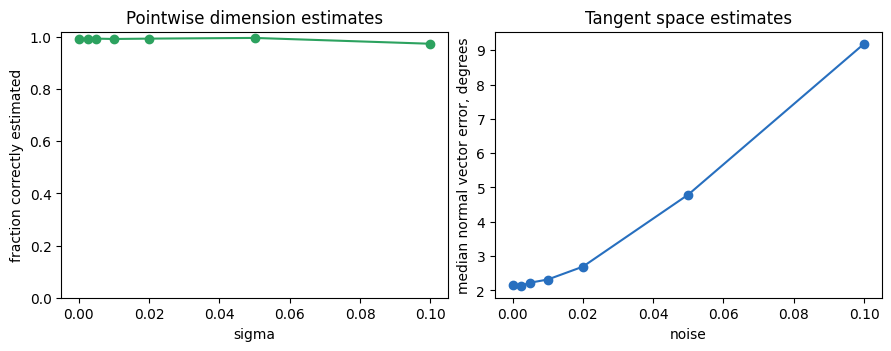

In [3]:
sigmas = np.array([0.0, 0.0025, 0.005, 0.01, 0.02, 0.05, 0.10])
summary = np.array([[noise_row(sample_sphere(), sigma, rep) for rep in range(3)] for sigma in sigmas]).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.4), constrained_layout=True)
axes[0].plot(sigmas, summary[:, 0], marker="o", color="#2ca25f")
axes[0].set_ylim(0, 1.02)
axes[0].set_xlabel("sigma")
axes[0].set_ylabel("fraction correctly estimated")
axes[0].set_title("Pointwise dimension estimates")
axes[1].plot(sigmas, summary[:, 1], marker="o", color="#276fbf")
axes[1].set_xlabel("noise")
axes[1].set_ylabel("median normal vector error, degrees")
axes[1].set_title("Tangent space estimates")

plt.show()
